<div class="alert alert-block alert-info">
<b>Number of points for this notebook:</b> 2
<br>
<b>Deadline:</b> October 28, 2025 (Tuesday) 23:59 (end of day)
</div>

# Exercise 2.1. Convolutional neural networks. LeNet-5.

In this exercise, you will train a very simple convolutional neural network used for image classification tasks.

If you are not fluent with PyTorch, you may find it useful to look at this tutorial:
* [Neural Networks](https://pytorch.org/tutorials/beginner/blitz/neural_networks_tutorial.html#sphx-glr-beginner-blitz-neural-networks-tutorial-py)

In [29]:
skip_training = True  # Set this flag to True before validation and submission

In [ ]:
# During evaluation, this cell sets skip_training to True
# skip_training = True

In [4]:
pip install torchvision

Note: you may need to restart the kernel to use updated packages.Requirement already satisfied: numpy in c:\users\guzma\anaconda3\lib\site-packages (from torchvision) (1.21.5)


ERROR: Could not install packages due to an OSError: [WinError 5] Acceso denegado: 'C:\\Users\\guzma\\AppData\\Local\\Temp\\pip-uninstall-bx_u2vlz\\_c.cp39-win_amd64.pyd'
Consider using the `--user` option or check the permissions.




  Attempting uninstall: typing-extensions
    Found existing installation: typing-extensions 4.9.0
    Uninstalling typing-extensions-4.9.0:
      Successfully uninstalled typing-extensions-4.9.0
  Attempting uninstall: sympy
    Found existing installation: sympy 1.13.1
    Uninstalling sympy-1.13.1:
      Successfully uninstalled sympy-1.13.1
  Attempting uninstall: torch
    Found existing installation: torch 2.5.1
    Uninstalling torch-2.5.1:
      Successfully uninstalled torch-2.5.1


In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

import torch
import torchvision
import torchvision.transforms as transforms

import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

import tools
import tests

In [3]:
import sys 
print(sys.executable)

c:\Users\guzma\4 IMAT\PRIMER CUATRI\Machines Learning and Perception\Practica 3\myenv\Scripts\python.exe


In [4]:
# When running on your own computer, you can specify the data directory by:
# data_dir = tools.select_data_dir('/your/local/data/directory')
data_dir = tools.select_data_dir()

The data directory is ../data


In [5]:
# Select the device for training (use GPU if you have one)
#device = torch.device('cuda:0')
device = torch.device('cpu')

In [6]:
if skip_training:
    # The models are always evaluated on CPU
    device = torch.device("cpu")

## FashionMNIST dataset

Let us use the FashionMNIST dataset. It consists of 60,000 training images of 10 classes: 'T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot'.

In [7]:
transform = transforms.Compose([
    transforms.ToTensor(),  # Transform to tensor
    transforms.Normalize((0.5,), (0.5,))  # Scale images to [-1, 1]
])

trainset = torchvision.datasets.FashionMNIST(root=data_dir, train=True, download=True, transform=transform)
testset = torchvision.datasets.FashionMNIST(root=data_dir, train=False, download=True, transform=transform)

classes = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal',
           'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

trainloader = torch.utils.data.DataLoader(trainset, batch_size=32, shuffle=True)
testloader = torch.utils.data.DataLoader(testset, batch_size=5, shuffle=False)

100.0%
100.0%
100.0%
100.0%


Let us visualize the data.

torch.Size([32])

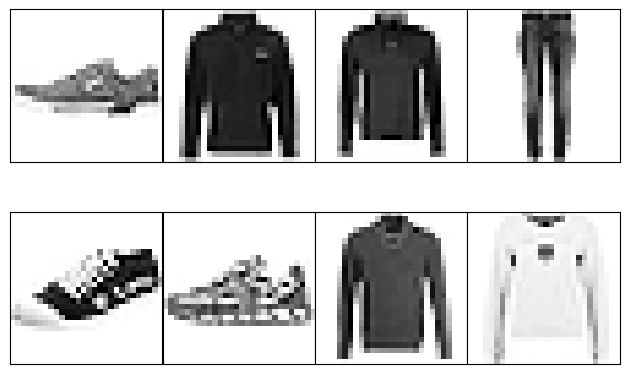

In [15]:
images, labels = next(iter(trainloader))
tests.plot_images(images[:8], n_rows=2)
images.shape 
labels.shape


# 1. Simple convolutional network

In the first exercise, your task is to create a convolutional neural network with the architecture inspired by the classical LeNet-5 [(LeCun et al., 1998)](http://yann.lecun.com/exdb/publis/pdf/lecun-01a.pdf).

The architecture of the convolutional network that you need to create:
* 2d convolutional layer with:
    * one input channel
    * 6 output channels
    * kernel size 5 (no padding)
    * followed by ReLU
* Max-pooling layer with kernel size 2 and stride 2
* 2d convolutional layer with:
    * 16 output channels
    * kernel size 5 (no padding)
    * followed by ReLU
* Max-pooling layer with kernel size 2 and stride 2
* A fully-connected layer with:
    * 120 outputs
    * followed by ReLU
* A fully-connected layer with:
    * 84 outputs
    * followed by ReLU
* A fully-connected layer with 10 outputs and without nonlinearity.

In [9]:
class LeNet5(nn.Module):
    def __init__(self):
        super(LeNet5, self).__init__()
        self.first_conv = nn.Conv2d(1,6,(5,5),stride=(1,1),padding=(0,0),dilation=(1,1))
        self.second_conv = nn.Conv2d(6,16,(5,5),stride=(1,1),padding=(0,0),dilation=(1,1))
        self.fc1 = nn.Linear(256,120,bias=True,device=device)
        self.fc2 = nn.Linear(120,84,bias=True,device=device)
        self.final = nn.Linear(84,10,bias=True,device=device)
        self.pooling_layer = nn.MaxPool2d(kernel_size=(2,2), stride=(2,2))


    def forward(self, x):
        """
        Args:
          x of shape (batch_size, 1, 28, 28): Input images. We do not have to make any changes
        
        Returns:
          y of shape (batch_size, 10): Outputs of the network.
        """
        c1 = F.relu(self.first_conv(x)) #the output has the shape (batch_size,6,24,24)
        p1 = self.pooling_layer(c1) #the shape is (batch_size,6,12,12)
        c2 = F.relu(self.second_conv(p1)) #the shape is (batch_size,16,8,8)
        p2 = self.pooling_layer(c2)#the shape is (batch_size,16,4,4)--> so the in features for the linear are: (batch_size,256)
        l1 = F.relu(self.fc1(torch.flatten(p2,start_dim=1))) #for applying the nn.Linear we need this form: (Batch_size,Channels*Height*Width). 
        l2 = F.relu(self.fc2(l1))
        final = self.final(l2)
        return final


In [10]:
def test_LeNet5_shapes():
    net = LeNet5()

    # Feed a batch of images from the training data to test the network
    with torch.no_grad():
        images, labels = next(iter(trainloader))
        print('Shape of the input tensor:', images.shape)

        y = net(images)
        assert y.shape == torch.Size([trainloader.batch_size, 10]), "Bad shape of y: y.shape={}".format(y.shape)

    print('Success')

test_LeNet5_shapes()

Shape of the input tensor: torch.Size([32, 1, 28, 28])
Success


In [11]:
tests.test_LeNet5(LeNet5)

y: tensor([[ 1.0000,  1.0000,  1.0000,  1.0000,  1.0000, -1.0000, -1.0000, -1.0000,
         -1.0000, -1.0000]], grad_fn=<AddmmBackward0>)
expected: tensor([ 1.,  1.,  1.,  1.,  1., -1., -1., -1., -1., -1.])
Success


# Train the network

In [12]:
# This function computes the accuracy on the test dataset
def compute_accuracy(net, testloader):
    net.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in testloader:
            images, labels = images.to(device), labels.to(device)
            outputs = net(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    return correct / total

### Training loop

Your task is to implement the training loop. The recommended hyperparameters:
* Stochastic Gradient Descent (SGD) optimizer with learning rate 0.001 and momentum 0.9.
* Cross-entropy loss. Note that we did not use softmax nonlinearity in the final layer of our network. Therefore, we need to use a loss function with log_softmax implemented, such as [`nn.CrossEntropyLoss`](https://pytorch.org/docs/stable/nn.html#torch.nn.CrossEntropyLoss).
* Number of epochs: 10. Please use mini-batches produces by `trainloader` defined above.

We recommend you to use function `compute_accuracy()` defined above to track the accuracy during training. The test accuracy should be above 0.87.

In [13]:
# Create network
net = LeNet5()

In [27]:
# Implement the training loop in this cell
num_epochs = 10
net.train()
if not skip_training:
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(params=net.parameters(),lr=0.001,momentum=0.9) 
    for i in range(num_epochs): 
        for images,labels in trainloader: 
            images = images.to(device)
            labels = labels.to(device)
            outputs = net(images)
            loss = criterion(outputs,labels)
            #backward and optimize: 
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            print(f'Epoch {i} and the loss is: {loss}')

Epoch 0 and the loss is: 2.2893924713134766
Epoch 0 and the loss is: 2.304982900619507
Epoch 0 and the loss is: 2.3133764266967773
Epoch 0 and the loss is: 2.304816246032715
Epoch 0 and the loss is: 2.3012661933898926
Epoch 0 and the loss is: 2.299887180328369
Epoch 0 and the loss is: 2.3117332458496094
Epoch 0 and the loss is: 2.309817314147949
Epoch 0 and the loss is: 2.304607629776001
Epoch 0 and the loss is: 2.2967004776000977
Epoch 0 and the loss is: 2.292813539505005
Epoch 0 and the loss is: 2.311537742614746
Epoch 0 and the loss is: 2.302694082260132
Epoch 0 and the loss is: 2.289268732070923
Epoch 0 and the loss is: 2.3009262084960938
Epoch 0 and the loss is: 2.288325548171997
Epoch 0 and the loss is: 2.3118252754211426
Epoch 0 and the loss is: 2.3057711124420166
Epoch 0 and the loss is: 2.308683156967163
Epoch 0 and the loss is: 2.2836861610412598
Epoch 0 and the loss is: 2.3111863136291504
Epoch 0 and the loss is: 2.3009979724884033
Epoch 0 and the loss is: 2.313408374786377


In [28]:
# Save the model to disk (the pth-files will be submitted automatically together with your notebook)
# Set confirm=False if you do not want to be asked for confirmation before saving.
if not skip_training:
    tools.save_model(net, '1_lenet5.pth', confirm=True)

Model saved to 1_lenet5.pth.


In [30]:
if skip_training:
    net = LeNet5()
    tools.load_model(net, '1_lenet5.pth', device)

Model loaded from 1_lenet5.pth.


Ground truth labels:  Ankle boot   Pullover    Trouser    Trouser      Shirt
Predictions:          Ankle boot   Pullover    Trouser    Trouser      Shirt


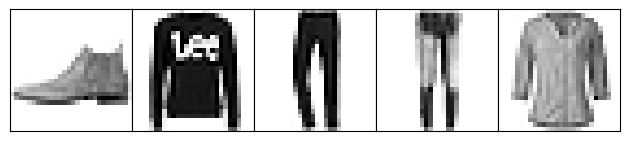

In [31]:
# Display random images from the test set, the ground truth labels and the network's predictions
net.eval()
with torch.no_grad():
    images, labels = next(iter(testloader))
    tests.plot_images(images[:5], n_rows=1)
    
    # Compute predictions
    images = images.to(device)
    y = net(images)

print('Ground truth labels: ', ' '.join('%10s' % classes[labels[j]] for j in range(5)))
print('Predictions:         ', ' '.join('%10s' % classes[j] for j in y.argmax(dim=1)))

In [32]:
# Compute the accuracy on the test set
accuracy = compute_accuracy(net, testloader)
print('Accuracy of the network on the test images: %.3f' % accuracy)
assert accuracy > 0.85, "Poor accuracy {:.3f}".format(accuracy)
print('Success')

Accuracy of the network on the test images: 0.861
Success
